In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches=pd.read_csv('matches.csv')
deliveries=pd.read_csv('deliveries.csv')

In [6]:
matches.head(2)


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [8]:
matches.isnull().sum()

id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

# Data Cleaning using pandas

In [4]:
matches['winner'].fillna('No Result',inplace=True)
matches['player_of_match'].fillna('Distributedt',inplace=True)

In [5]:
matches.drop_duplicates(inplace=True)

In [6]:
matches['date']=pd.to_datetime(matches['date'],format='%d-%m-%Y')

In [7]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [7]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

In [24]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype: int64

# Team Analysis

# EDA(visualization)

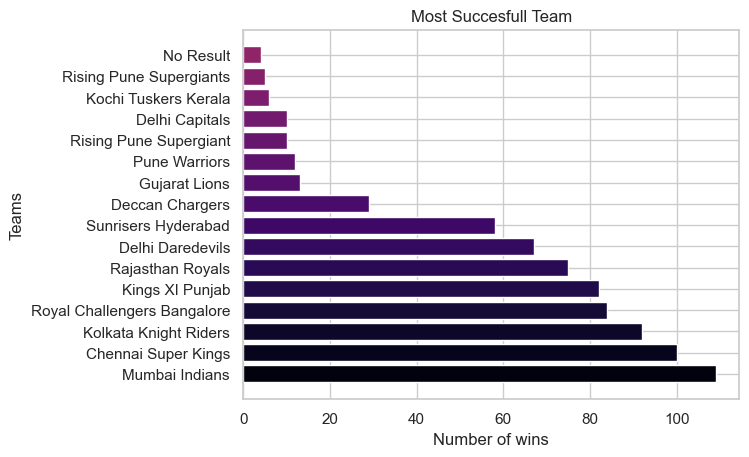

In [29]:

team_wins = matches['winner'].value_counts()
plt.barh(team_wins.index,
         team_wins.values, data=matches,color=sns.color_palette('inferno',40))
sns.set_theme(style="darkgrid")
plt.title('Most Succesfull Team')
plt.xlabel('Number of wins')
plt.ylabel('Teams')
plt.show()

### Insight:
Mumbai Indians is the most successful IPL team based on total match wins.


# Toss winning vs Match winning 

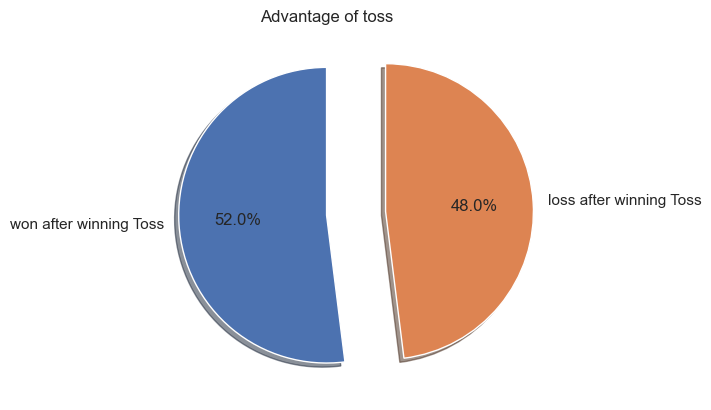

In [31]:
result=(matches['toss_winner'] == matches['winner']).value_counts()
plt.pie(result,
       labels=['won after winning Toss',
              'loss after winning Toss'],autopct='%1.1f%%',explode=(0,0.4),startangle=90,shadow=1
           )
plt.title('Advantage of toss')
plt.show()


### insight
Toss does not affecting too much to winning percentage

# Team wins at each venue

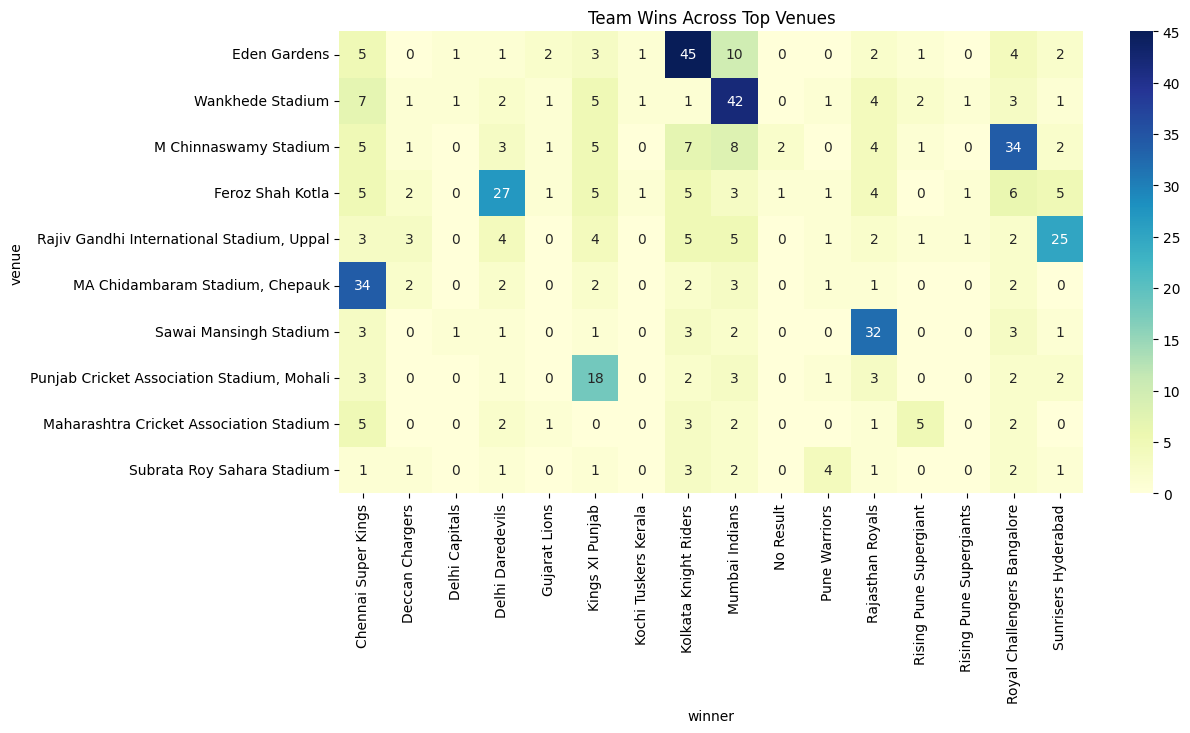

In [9]:
venue_team = pd.crosstab(
    matches['venue'],
    matches['winner']
)

top_venues = venue_team.sum(axis=1).sort_values(
    ascending=False
).head(10).index

plt.figure(figsize=(12,6))

sns.heatmap(
    venue_team.loc[top_venues],
    annot=True,
    cmap='YlGnBu'
)

plt.title("Team Wins Across Top Venues")
plt.show()

### Insight
Each team win their most matches at home ground

# PLAYER ANALYSIS

# Top Run Scorer

In [14]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


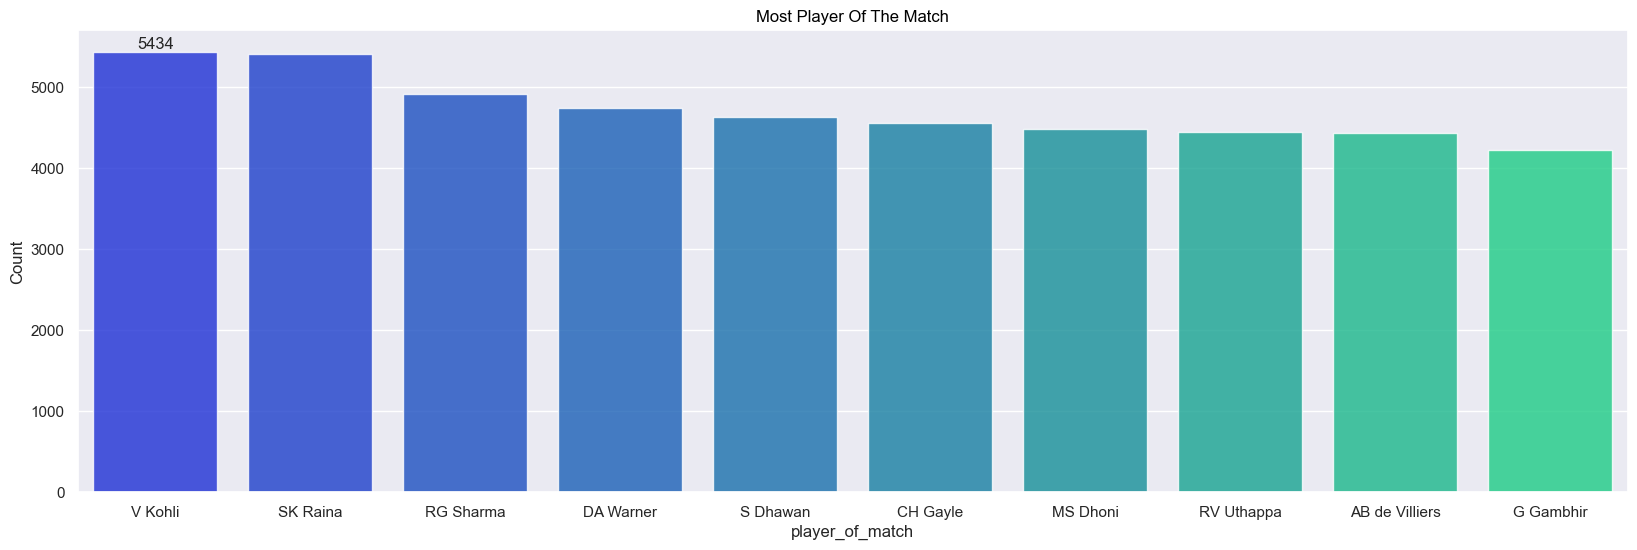

In [54]:
most_runs=deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)



sns.set_style("darkgrid")
plt.figure(figsize=(20,6))
a=sns.barplot(x=most_runs.index, y=most_runs.values, alpha=0.8,hue=most_runs.index,palette='winter')
plt.title('Most Player Of The Match',color='black')
plt.ylabel('Count', fontsize=12)
plt.xlabel('player_of_match', fontsize=12)

a.bar_label(a.containers[0])


plt.show()

### insight
Virat kohli is highest run scorer in ipl history

Text(0, 0.5, 'count')

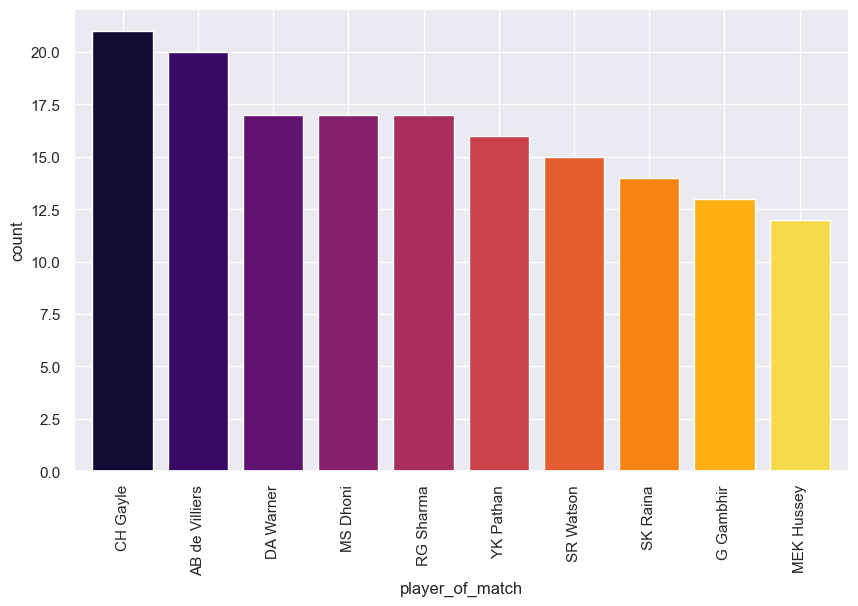

In [55]:
plt.subplots(figsize=(10,6))

ax=matches['player_of_match'].value_counts().head(10).plot.bar(width=0.8,color=sns.color_palette('inferno',10))

ax.set_xlabel('player_of_match')
ax.set_ylabel('count')


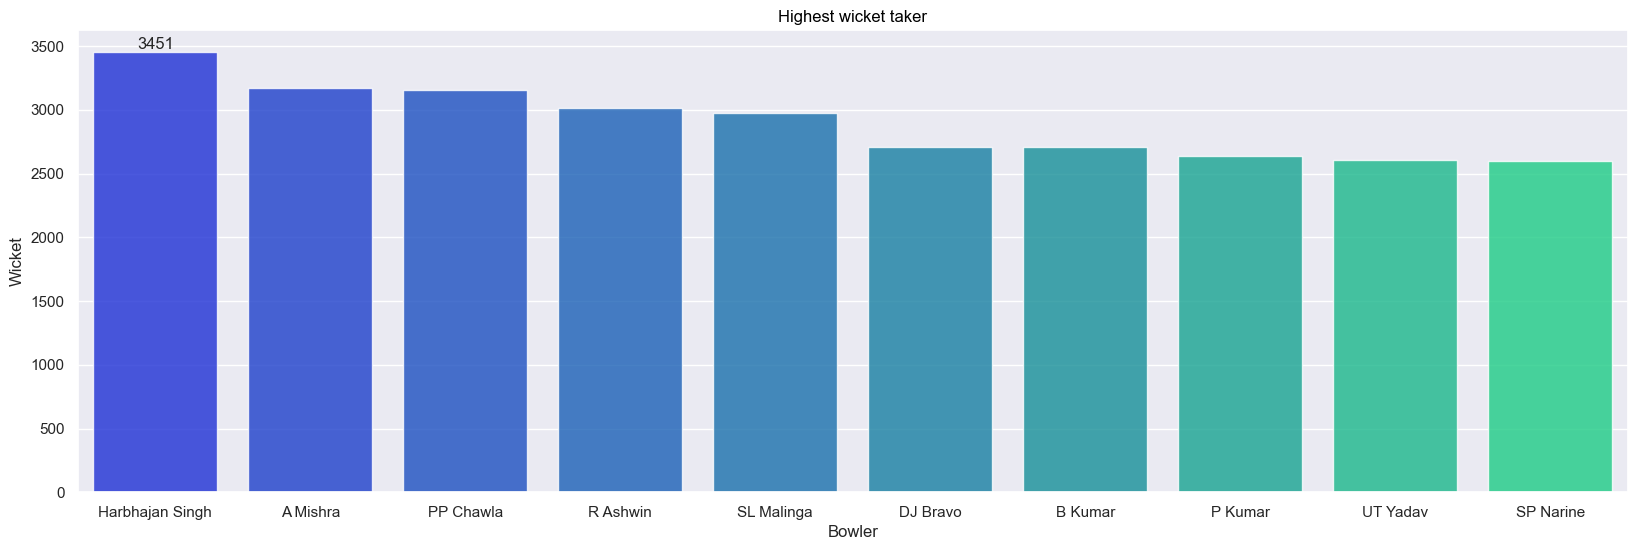

In [63]:
most_wick=deliveries['bowler'].value_counts().sort_values(ascending=False).head(10)

sns.set_style("darkgrid")
plt.figure(figsize=(20,6))
a=sns.barplot(x=most_wick.index, y=most_wick.values, alpha=0.8,hue=most_wick.index,palette='winter')
plt.title('Highest wicket taker',color='black')
plt.ylabel('Wicket', fontsize=12)
plt.xlabel('Bowler', fontsize=12)

a.bar_label(a.containers[0])


plt.show()